#One Shot Learning with Siamese Networks

## Reading data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install feather-format

  Preparing metadata (setup.py) ... done
  Created wheel for feather-format: filename=feather_format-0.4.1-py3-none-any.whl size=2434 sha256=22b0f7120794708cf65cd68650c9f5c15ace22f25ae39f33e36e101a3a40fa79
  Stored in directory: /root/.cache/pip/wheels/dd/02/6b/2f0f7e1c0454094c880e63076da142e67f1ba72f82baa6195f
Successfully built feather-format


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import feather

# path to the data directory
path = '/content/drive/My Drive/bubPaterns'
os.chdir(path)
#!ls
#os.listdir(path)

# number of groups (species, processes, ...)
n_classes = 9
# number of replicates (censuses, ...)
n_examples = 6

# rectangular observation window
xmin = 0
xmax = 29
ymin = 0
ymax = 19.2
window = [[xmin, xmax], [ymin, ymax]]

# grid dimension
grid_nx = 290
grid_ny = 192

In [ ]:
# dictionary with n_classs number of elements
species = ['5_5', '5_8', '5_10', '10_5', '10_8',
    '10_10', '15_5', '15_8', '15_10']

In [ ]:
# read data files: each point pattern in a separate file
bci_patterns = [None] * n_classes
filename = [None] * n_examples
for i in range(n_classes):
  bci_patterns[i] = [None] * n_examples
  for j in range(n_examples):
    filename[j] = species[i] + str(j + 1) + ".feather"
    df = feather.read_dataframe(filename[j])
    bci_patterns[i][j] = df

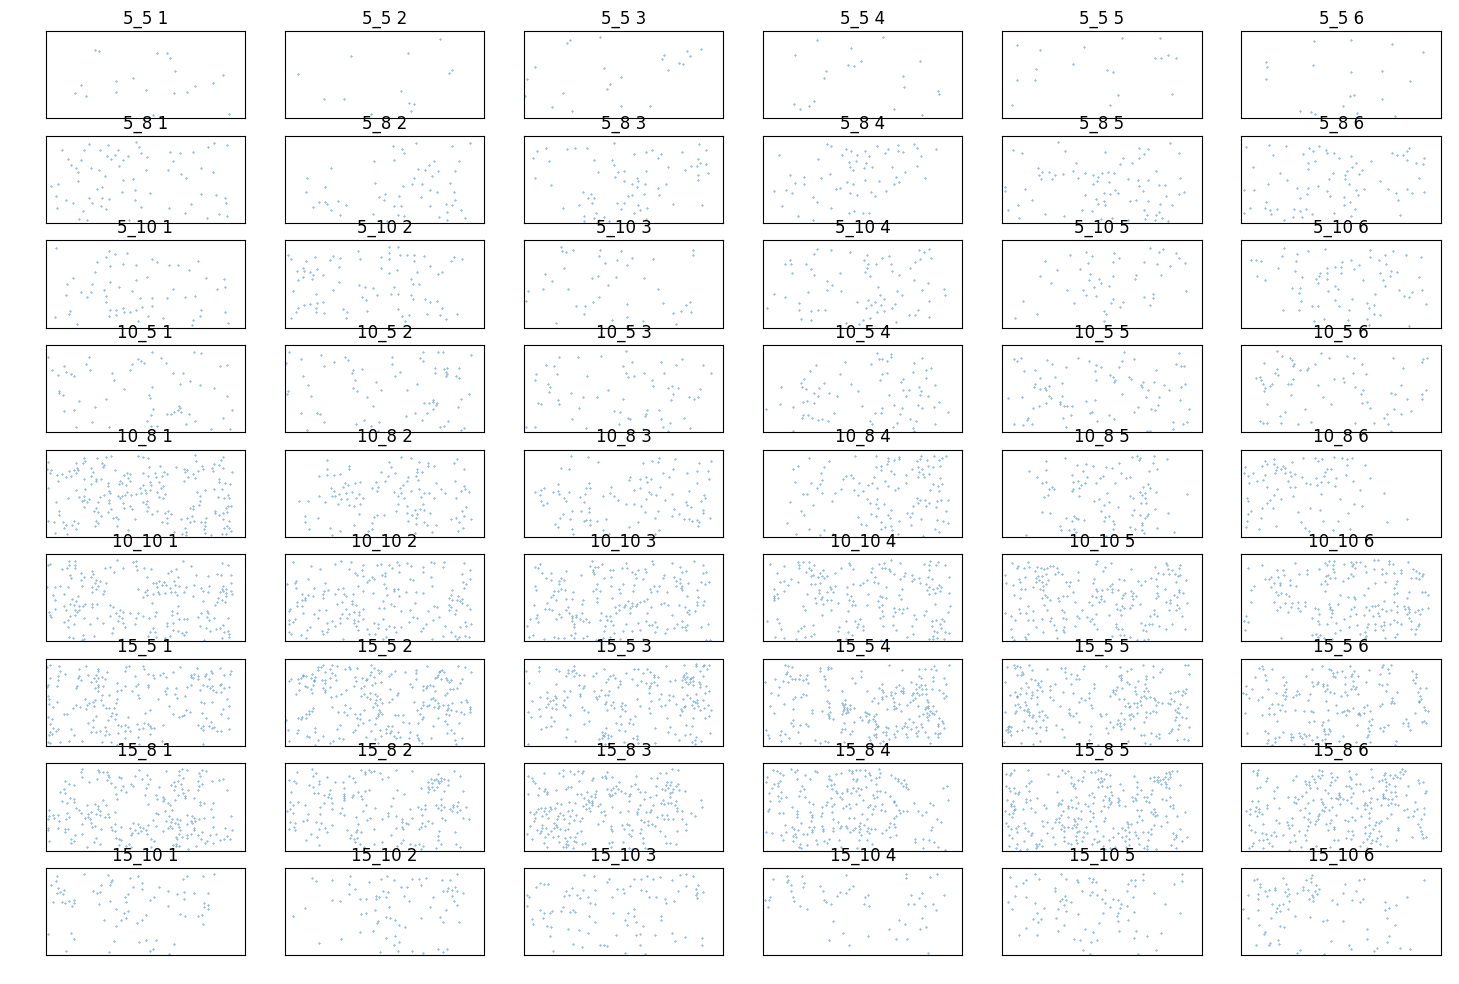

In [ ]:
fig, axs = plt.subplots(9, 6, figsize=(18, 12))

for i in range(n_classes):
  for j in range(n_examples):
    axs[i, j].scatter(bci_patterns[i][j]['x'], bci_patterns[i][j]['y'], s=0.1)
    axs[i, j].set_title(species[i] + ' ' + str(j + 1))
    axs[i, j].set_xlim([0, 1])
    axs[i, j].set_ylim([0, 1])
    #axs[i, j].axis('off')
    axs[i, j].set_xticks(window[0])
    axs[i, j].set_yticks(window[1])
    axs[i, j].tick_params(axis='both', which='both',length=0, labelcolor='white')

fig.savefig('bcipatterns.pdf', bbox_inches='tight')

## Convert spatial point patterns to images (spatial counts)

In [ ]:
def pattern2img(pp, nx, ny, window):
  x = pp['x']
  y = pp['y']
  grid = np.histogram2d(x, y, bins=[nx, ny], range=window, density=False)[0]
  return np.transpose(grid)

bci_imgs = [None] * n_classes
for i in range(n_classes):
  bci_imgs[i] = [None] * n_examples
  for j in range(n_examples):
    bci_imgs[i][j] = pattern2img(bci_patterns[i][j], grid_nx, grid_ny, window)

bci_imgs = np.asarray(bci_imgs)
print(bci_imgs.shape)

(9, 6, 192, 290)


In [ ]:
print(bci_imgs.sum())
print(bci_imgs.mean())
print(bci_imgs.max())

6651.0
0.002212045019157088
1.0


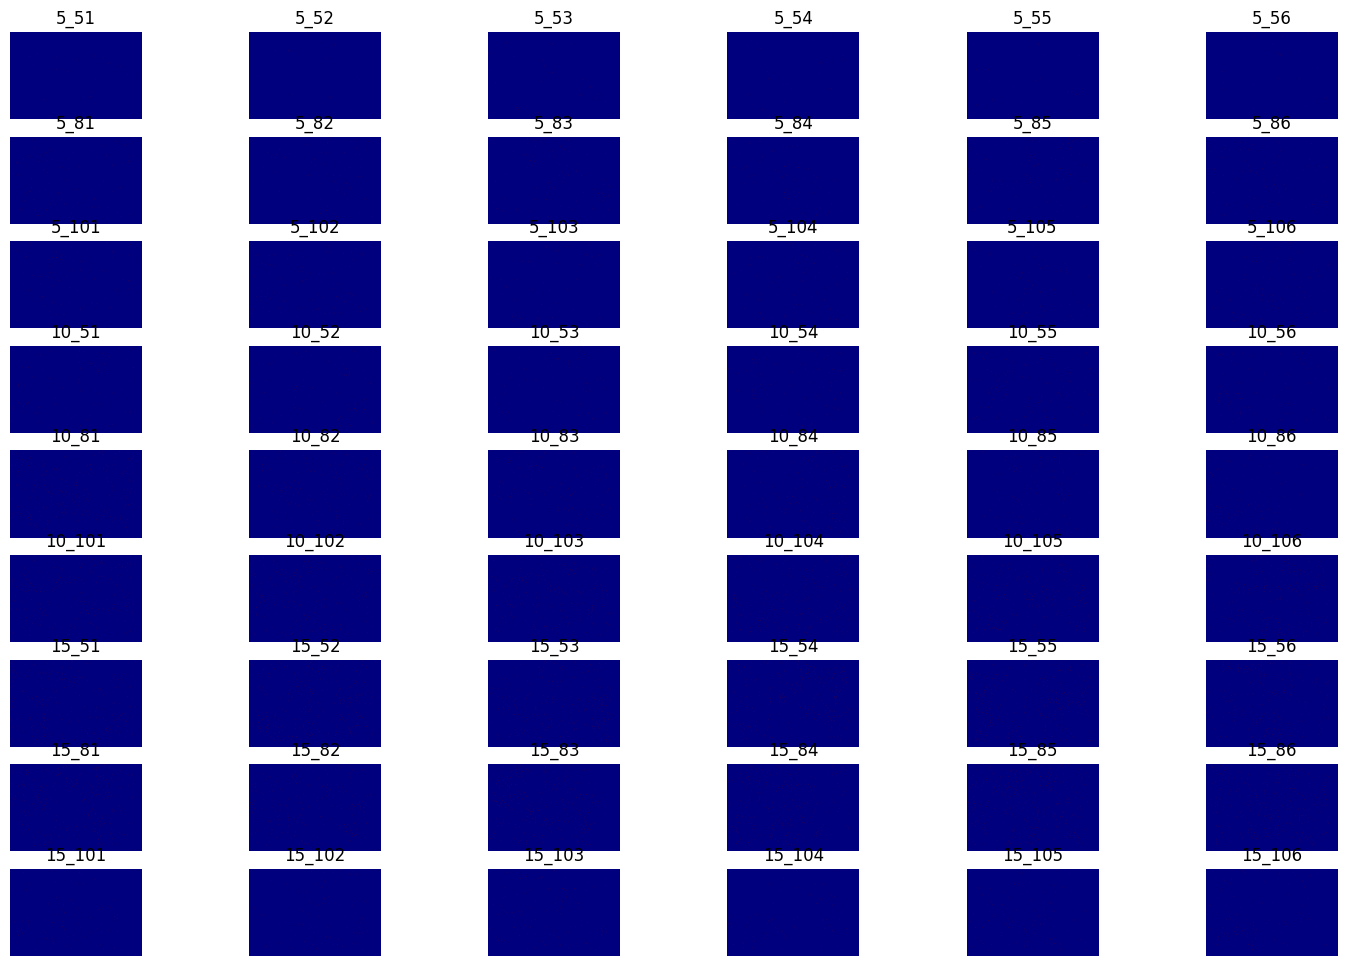

In [ ]:
fig, axs = plt.subplots(9, 6, figsize=(18, 12))

for i in range(n_classes):
  for j in range(n_examples):
    axs[i, j].imshow(bci_imgs[i][j], vmin=0, vmax=bci_imgs.max(), cmap='jet')
   # axs[i, j].scatter(bci_patterns[i][j]['x'] * grid_nx,
   #                   bci_patterns[i][j]['y'] * grid_ny, s=0.15, color='red')
    axs[i, j].set_title(species[i] + str(j + 1))
    axs[i, j].axis('off')
#fig.savefig('simimgs.pdf', bbox_inches='tight')

In [ ]:
print(np.sum(bci_imgs, axis=(2, 3)))

[[ 20.  13.  23.  20.  19.  20.]
 [ 73.  58.  72.  64.  82.  81.]
 [ 64.  84.  45.  76.  51.  77.]
 [ 65.  74.  66.  80.  91.  77.]
 [214. 123. 108. 127. 102.  90.]
 [208. 192. 206. 194. 207. 197.]
 [211. 247. 222. 243. 240. 197.]
 [230. 190. 242. 229. 284. 255.]
 [ 80.  77.  99.  59.  90.  93.]]


## Computing intensity and K functions with 'spatstat'

In [ ]:
# install the R package spatstat
from rpy2.robjects.packages import importr
utils = importr('utils') #-- Only once.
utils.install_packages('spatstat')

(as ‘lib’ is unspecified)



















	‘/tmp/Rtmpf8LVVp/downloaded_packages’



<rpy2.rinterface_lib.sexp.NULLType object at 0x7ee0a848a610> [0]

In [ ]:
import rpy2.robjects.packages as packages
# load spatstat
spatstat = importr('spatstat')
#from spatstat import *

import pandas as pd
from rpy2.robjects import pandas2ri
pandas2ri.activate()

In [ ]:
import rpy2.robjects as robjects
from rpy2.robjects import numpy2ri
from rpy2.robjects.packages import importr

# Aktifkan konversi otomatis NumPy <-> R
numpy2ri.activate()

# Import library R
spatstat_geom = importr('spatstat.geom')
spatstat_explore = importr('spatstat.explore')

# Window dari spatstat.geom
window = [0, 100]
W = spatstat_geom.owin(
    xrange=robjects.FloatVector(window),
    yrange=robjects.FloatVector(window)
)

# Cek berhasil
print(W)

window: rectangle = [0, 100] x [0, 100] units



In [ ]:
#import rpy2.robjects as robjects
#W = spatstat.owin(xrange=robjects.vectors.FloatVector(window[0]),
#              yrange=robjects.vectors.FloatVector(window[1]))
#dimyx = robjects.vectors.FloatVector([80, 160])

#bci_rhos = [None] * n_classes
#bci_Ks = [None] * n_classes
#for i in range(n_classes):
#  bci_rhos[i] = [None] * n_examples
#  bci_Ks[i] = [None] * n_examples
#  for j in range(n_examples):
#   pp = spatstat.ppp(bci_patterns[i][j]['x'], bci_patterns[i][j]['y'], window=W)
#    dd = spatstat.adaptive_density(pp, dimyx=dimyx)
#    bci_rhos[i][j] = np.array(dd.rx2('v'))
#   kk = spatstat.Kinhom(pp, dd, r=np.arange(0, 50, 0.25), correction='translation').rx2('trans')
#    bci_Ks[i][j] = np.array(kk)
# print(i)

#bci_rhos = np.asarray(bci_rhos)
#bci_Ks = np.asarray(bci_Ks)

#print(bci_rhos.shape)
#print(bci_Ks.shape)

In [ ]:
import numpy as np
import rpy2.robjects as robjects
from rpy2.robjects import numpy2ri
from rpy2.robjects.packages import importr
numpy2ri.activate()

spatstat_geom    = importr('spatstat.geom')
spatstat_explore = importr('spatstat.explore')

W = spatstat_geom.owin(
    xrange=robjects.FloatVector([0.0, 1.0]),
    yrange=robjects.FloatVector([0.0, 1.0])
)
dimyx = robjects.IntVector([120, 180])  # <-- integer!
r_grid = robjects.FloatVector(np.arange(0.0, 15.0, 0.1))

bci_rhos = [None] * n_classes
bci_Ks   = [None] * n_classes

for i in range(n_classes):
    bci_rhos[i] = [None] * n_examples
    bci_Ks[i]   = [None] * n_examples
    for j in range(n_examples):
        x = np.asarray(bci_patterns[i][j]['x'], dtype=float)
        y = np.asarray(bci_patterns[i][j]['y'], dtype=float)

        # --- normalisasi ke [0,1] supaya sesuai window
        x = (x - x.min()) / (x.max() - x.min() + 1e-12)
        y = (y - y.min()) / (y.max() - y.min() + 1e-12)

        pp = spatstat_geom.ppp(
            robjects.FloatVector(x),
            robjects.FloatVector(y),
            window=W
        )

        dd = spatstat_explore.adaptive_density(pp, dimyx=dimyx)
        bci_rhos[i][j] = np.array(dd.rx2('v'))

        # --> beri nama argumen 'lambda' (pakai lambda_ di Python)
        kk = spatstat_explore.Kinhom(
            pp, lambda_=dd, r=r_grid, correction='translation'
        ).rx2('trans')

        bci_Ks[i][j] = np.array(kk)
    print(i)

bci_rhos = np.asarray(bci_rhos)
bci_Ks = np.asarray(bci_Ks)

print(bci_rhos.shape)
print(bci_Ks.shape)

0
1
2
3
4
5
6
7
8
(9, 6, 120, 180)
(9, 6, 150)


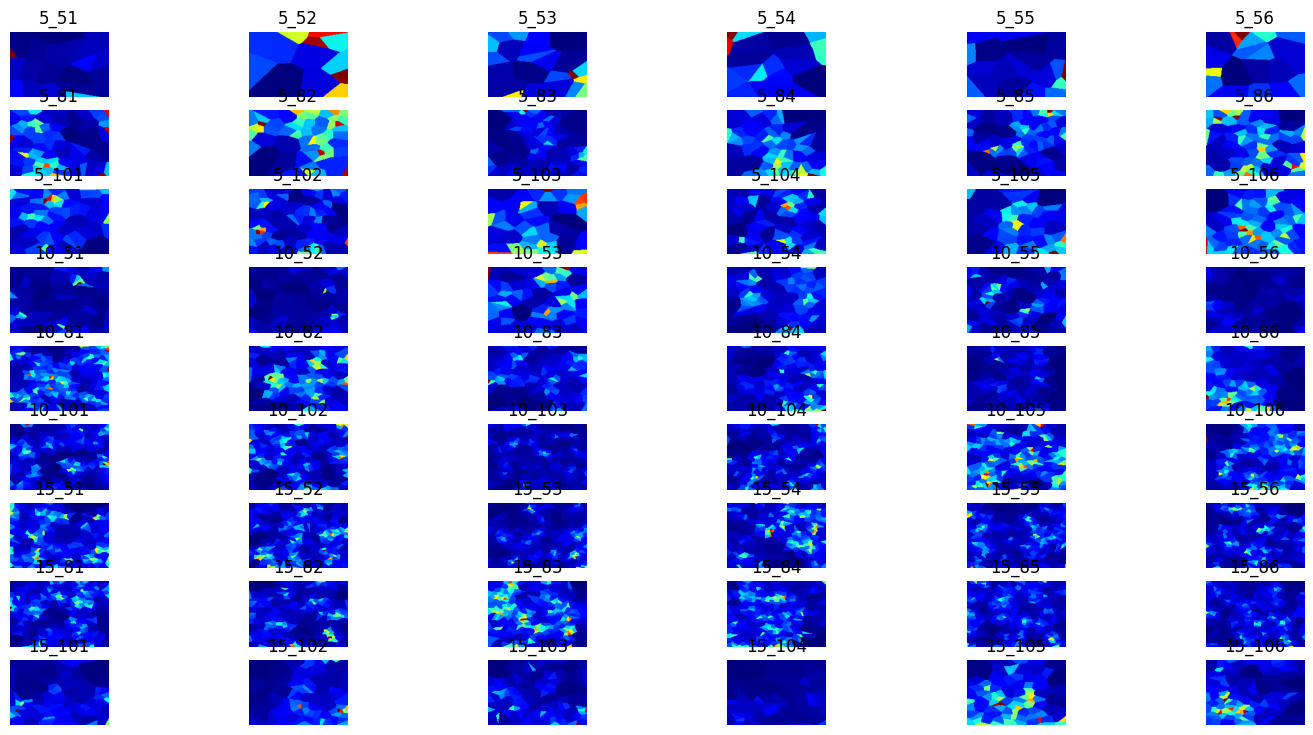

In [ ]:
fig, axs = plt.subplots(9, 6, figsize=(18, 9))

for i in range(n_classes):
  for j in range(n_examples):
    axs[i, j].imshow(bci_rhos[i][j],  cmap='jet')#, vmin=0, vmax=bci_rhos.max())
   # axs[i, j].scatter(bci_patterns[i][j]['x'] * 128,
   #                   bci_patterns[i][j]['y'] * 128, s=1, color='red')
    axs[i, j].set_title(species[i] + str(j + 1))
    axs[i, j].axis('off')
#fig.savefig('simrhos.pdf', bbox_inches='tight')

## Prepare traning and validating sets

In [ ]:
X = bci_imgs / bci_imgs.max()
print(X.shape)
y = []
for i in range(n_classes * n_examples *  grid_nx * grid_ny):
  y.append(int(i / (n_examples * grid_nx * grid_ny)))
y = np.asarray(y)
y = y.reshape([n_classes * n_examples * grid_nx * grid_ny, 1])
print(y.shape)

(9, 6, 192, 290)
(3006720, 1)


In [ ]:
import numpy.random as rng
n_test = 2

Xtrain = np.zeros([n_classes, n_examples - n_test, grid_ny, grid_nx])
Xval = np.zeros([n_classes, n_test, grid_ny, grid_nx])

for i in range(n_classes):
  val_idx = np.random.choice(n_examples, size=n_test, replace=False)
  Xtrain[i, :, :, :] = np.delete(X[i, :, :, :], val_idx, axis=0)
  Xval[i, :, :, :] = X[i, val_idx, :, :]

print(Xtrain.shape)
print(Xval.shape)

ytrain = []
for i in range(n_classes * (n_examples - n_test) *  grid_ny * grid_nx):
  ytrain.append(int(i / ((n_examples - n_test) * grid_ny * grid_nx)))
ytrain = np.asarray(ytrain)
ytrain = ytrain.reshape([n_classes * (n_examples - n_test) * grid_ny * grid_nx, 1])
yval = []
for i in range(n_classes * n_test *  grid_ny * grid_nx):
  yval.append(int(i / (n_test * grid_ny * grid_nx)))
yval = np.asarray(yval)
yval = yval.reshape([n_classes * n_test * grid_ny * grid_nx, 1])

print(ytrain.shape)
print(yval.shape)

(9, 4, 192, 290)
(9, 2, 192, 290)
(2004480, 1)
(1002240, 1)


In [ ]:
def get_batch(batch_size, s = "train"):
    """
    Create batch of n pairs, half same class, half different class
    """
    if s == 'train':
        X = Xtrain
        categories = ytrain
    else:
        X = Xval
        categories = yval
    n_classes, n_examples, h, w = X.shape

    # randomly sample several classes to use in the batch
    categories = rng.choice(n_classes, size=(batch_size,), replace=True)

    # initialize 2 empty arrays for the input image batch
    pairs=[np.zeros((batch_size, h, w, 1)) for i in range(2)]

    # initialize vector for the targets
    targets=np.zeros((batch_size,))

    # make one half of it '1's, so 2nd half of batch has same class
    targets[batch_size // 2:] = 1
    for i in range(batch_size):
        category = categories[i]
        idx_1 = rng.randint(0, n_examples)
        pairs[0][i, :, :, :] = X[category, idx_1].reshape(h, w, 1)
        idx_2 = rng.randint(0, n_examples)

        # pick images of same class for 1st half, different for 2nd
        if i >= batch_size // 2:
            category_2 = category
        else:
            # add a random number to the category modulo n classes to ensure 2nd image has a different category
            category_2 = (category + rng.randint(1, n_classes)) % n_classes

        pairs[1][i, :, :, :] = X[category_2, idx_2].reshape(h, w, 1)

    return pairs, targets

In [ ]:
def generate(batch_size, s="train"):
    """
    a generator for batches, so model.fit_generator can be used.
    """
    while True:
        pairs, targets = get_batch(batch_size, s)
        yield (pairs, targets)

## Siamese network

In [ ]:
from tensorflow.keras.layers import Input, Conv2D, Lambda, Dense, Flatten,MaxPooling2D, concatenate, Dropout
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.constraints import Constraint
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adadelta
from tensorflow.keras.regularizers import l1, l2
from tensorflow.keras.utils import plot_model
from tensorflow.keras import backend as K

import tensorflow as tf
print(tf.__version__)

2.19.0


In [ ]:
def make_oneshot_task(N, s="val"):
    """Create pairs of test image, support set for testing N way one-shot learning. """
    if s == 'train':
        X = Xtrain
        categories = ytrain
    else:
        X = Xval
        categories = yval
    n_classes, n_examples, h, w = X.shape

    categories = rng.choice(range(n_classes), size=(N,), replace=True)
    indices = rng.randint(0, n_examples, size=(N,))

    true_category = categories[0]
    ex1, ex2 = rng.choice(n_examples, replace=False, size=(2,))
    test_image = np.asarray([X[true_category, ex1,:,:]] * N).reshape(N, h, w, 1)
    indices[0] = ex2
    support_set = X[categories, indices, :, :]
    #support_set[0, :, :] = X[true_category, ex2]
    support_set = support_set.reshape(N, h, w, 1)
    targets = np.zeros((N,))
    targets[0] = 1
   # targets, test_image, support_set = shuffle(targets, test_image, support_set)
    pairs = [test_image, support_set]
    ## aj
    cat = categories
    ind = [ex1, indices]
    ## aj
    return pairs, targets, cat, ind


def test_oneshot(model, N, k, s = "val", verbose = 0):
    """Test average N way oneshot learning accuracy of a siamese neural net over k one-shot tasks"""
    n_correct = 0
    if verbose:
        print("Evaluating model on {} random {} way one-shot learning tasks ... \n".format(k, N))
    for i in range(k):
        inputs, targets, __, __ = make_oneshot_task(N, s)
        probs = model.predict(inputs)
        if np.argmax(probs) == np.argmax(targets):
            n_correct += 1
    percent_correct = (100.0 * n_correct / k)
    if verbose:
        print("Got an average of {}% {} way one-shot learning accuracy \n".format(percent_correct,N))
    return percent_correct

In [ ]:
def get_siamese_model(input_shape):
    """
        Model architecture
    """

    # Define the tensors for the two input images
    left_input = Input(input_shape)
    right_input = Input(input_shape)

    # Convolutional Neural Network
    model = Sequential()
    model.add(Dropout(rate=0.1))
    model.add(Conv2D(filters=32, kernel_size=(10, 20), strides=1,
                     padding='valid', activation='relu', input_shape=input_shape,
                     kernel_regularizer=l2(1e-4), #bias_regularizer=l2(1e-2),
                     bias_initializer='zeros', kernel_initializer='glorot_uniform'
                     ))
    model.add(MaxPooling2D(pool_size=(2, 2), padding='valid'))
    model.add(Dropout(rate=0.1))
    model.add(Conv2D(filters=64, kernel_size=(7, 14), strides=1,
                     padding='valid', activation='relu',
                     kernel_regularizer=l2(1e-4), #bias_regularizer=l2(1e-2),
                     bias_initializer='zeros', kernel_initializer='glorot_uniform'
                     ))
    model.add(MaxPooling2D(pool_size=(2, 2), padding='valid'))
    model.add(Conv2D(filters=64, kernel_size=(4, 8), strides=1,
                     padding='valid', activation='relu',
                     kernel_regularizer=l2(1e-4), #bias_regularizer=l2(1e-2),
                     bias_initializer='zeros', kernel_initializer='glorot_uniform'
                     ))
    model.add(MaxPooling2D(pool_size=(2, 2), padding='valid'))
    model.add(Conv2D(filters=128, kernel_size=(4, 8), strides=1,
                     padding='valid', activation='relu',
                     kernel_regularizer=l2(1e-4), #bias_regularizer=l2(1e-2),
                     bias_initializer='zeros', kernel_initializer='glorot_uniform'
                     ))
    model.add(MaxPooling2D(pool_size=(2, 2), padding='valid'))
    model.add(Flatten())
    model.add(Dense(2048, activation='sigmoid', use_bias=True,
                    kernel_regularizer=l2(1e-3)
                    ))

    # Generate the encodings (feature vectors) for the two images
    encoded_l = model(left_input)
    encoded_r = model(right_input)

    # Add a customized layer to compute the absolute difference between the encodings
    L1_layer = Lambda(lambda tensors:K.abs(tensors[0] - tensors[1]))
    L1_distance = L1_layer([encoded_l, encoded_r])

    # Add a dense layer with a sigmoid unit to generate the similarity score
    prediction = Dense(1, activation='sigmoid')(L1_distance)#, bias_initializer=initialize_bias)(L1_distance)

    # Connect the inputs with the outputs
    siamese_net = Model(inputs=[left_input, right_input], outputs=prediction)

    # return the model
    return siamese_net

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


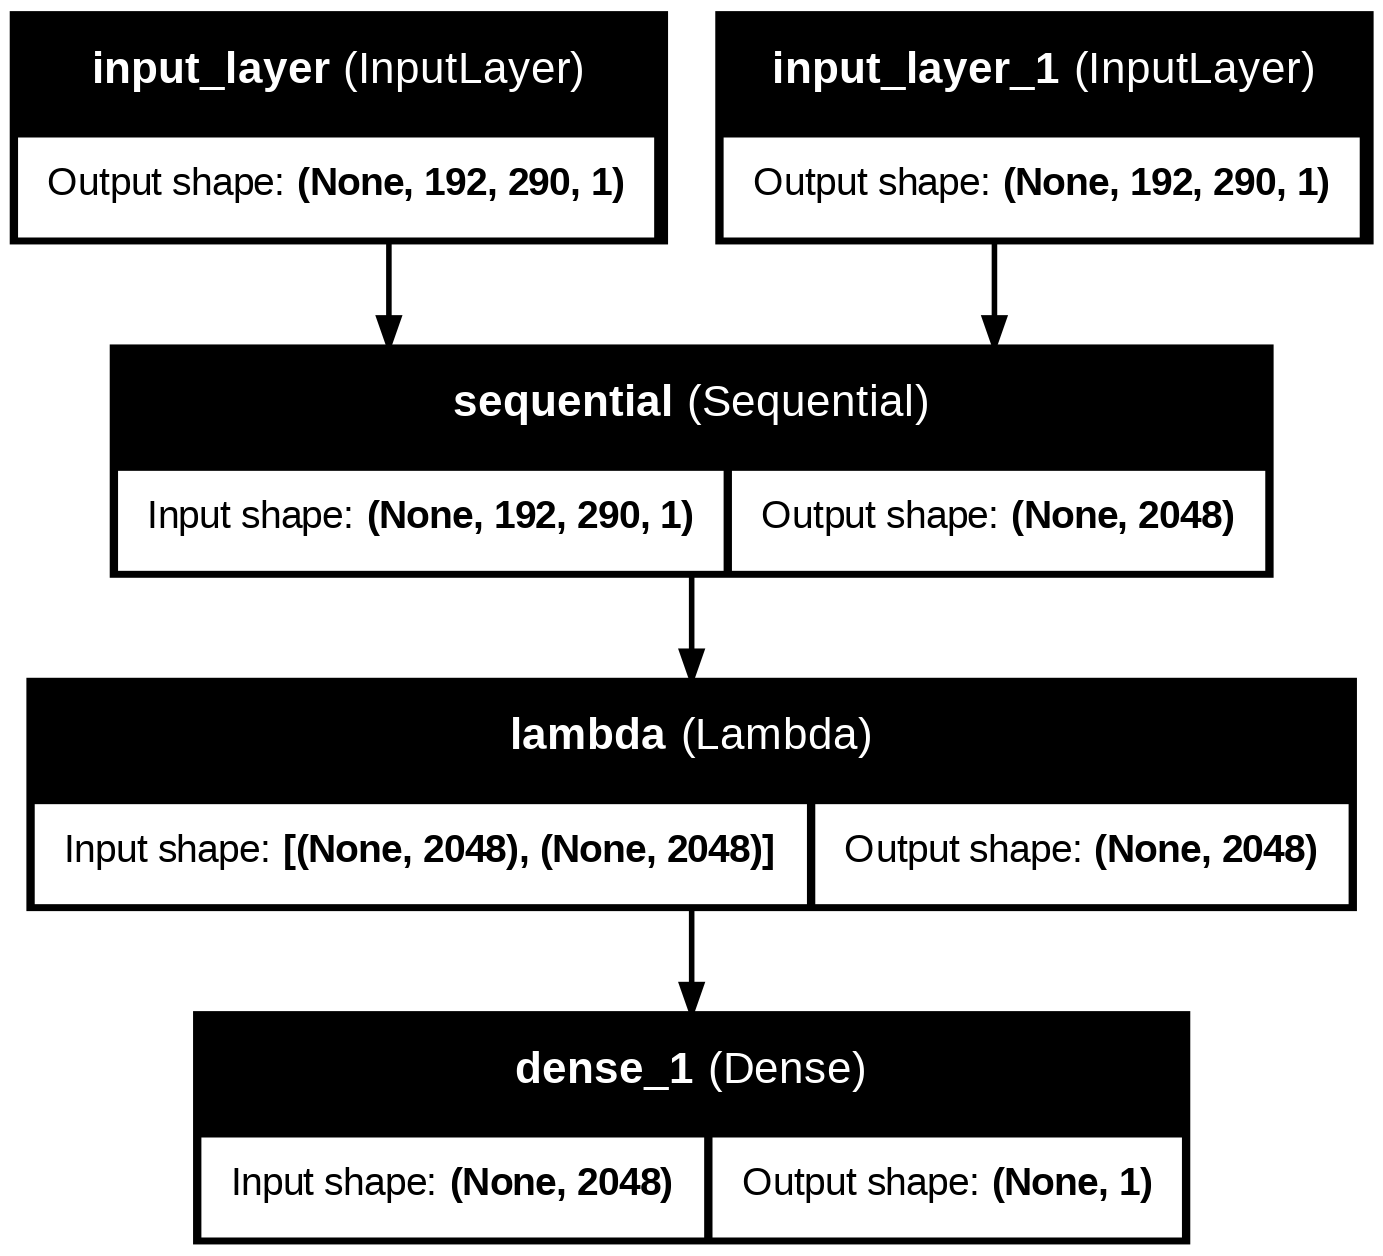

In [ ]:
input_shape = (grid_ny, grid_nx, 1)
model = get_siamese_model(input_shape)
plot_model(model, show_shapes=True, show_layer_names=True)

In [ ]:
optimizer =Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)
model.compile(loss="binary_crossentropy", optimizer=optimizer)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 192, 290,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 192, 290,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 2048)      │ 21,574,176 │ input_layer[0][0… │
│ (Sequential)        │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 2048)      │          0 │ sequential[0][0], │
│                     │                   │            │ sequential[1][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │      2,049 │ lambda[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 21,576,225 (82.31 MB)

 Trainable params: 21,576,225 (82.31 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#def reset_weights(model):
#    for layer in model.layers:
#        if hasattr(layer, 'bias_initializer'):
#            layer.bias.initializer.run(session=K.get_session())
#        if hasattr(layer, 'kernel_initializer'):
#            layer.kernel.initializer.run(session=K.get_session())
#reset_weights(model)
# model.get_weights()

AttributeError: 'Variable' object has no attribute 'initializer'

In [ ]:
import time
import numpy as np

model_path = './weights/'

# Hyper parameters
evaluate_every = 50 # interval for evaluating on one-shot tasks
batch_size = 8 # Changed batch_size to be less than or equal to n_classes
n_iter = 1000 #20000 # No. of training iterations
N_way = 9 # how many classes for testing one-shot tasks
n_val = 250 # how many one-shot tasks to validate on
best = -1

loss = np.zeros(n_iter)
val_acc, train_acc = [], []
val_index = 0
print("Starting training process!")
print("-------------------------------------")
t_start = time.time()
for i in range(n_iter):
    (inputs, targets) = get_batch(batch_size)
    loss[i] = model.train_on_batch(inputs, targets)
    #if (i + 1) % 2 == 0:
    # K.set_value(model.optimizer.learning_rate, K.get_value(model.optimizer.learning_rate) * 0.99) # Old way
    new_lr = model.optimizer.learning_rate * 0.99
    model.optimizer.learning_rate.assign(new_lr) # New way
    if (i + 1) % evaluate_every == 0:
        print("\n ------------- \n")
        print("Time for {0} iterations: {1} mins".format(i + 1, (time.time() - t_start)/60.0))
        print("Train Loss: {0}".format(loss[i]))
        print("Learning Rate: {0}".format(model.optimizer.learning_rate.numpy())) # Access as numpy value for printing
        val_acc.append(test_oneshot(model, N_way, n_val, verbose=True))
        train_acc.append(test_oneshot(model, N_way, n_val, s='train', verbose=True))
        #model.save_weights(os.path.join(model_path, 'weights.{}.h5'.format(i)))
        if val_acc[val_index] >= best:
            print("Current best: {0}, previous best: {1}".format(val_acc[val_index], best))
            best = val_acc[val_index]
        val_index += 1

val_acc = np.array(val_acc)

Streaming output truncated to the last 5000 lines.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98

0.32888904213905334
4.126204013824463


np.float32(4.3171656e-08)

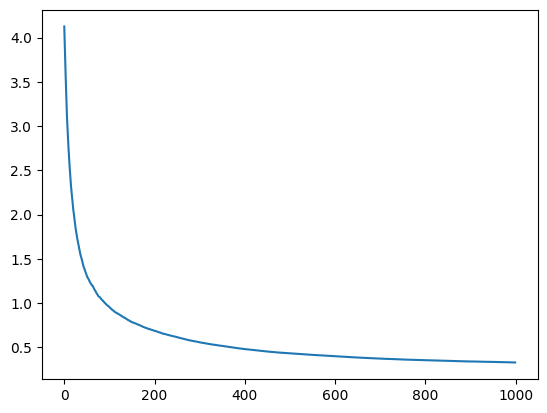

In [ ]:
plt.plot(loss)
print(loss.min())
print(loss.max())
K.eval(model.optimizer.learning_rate)

40.8


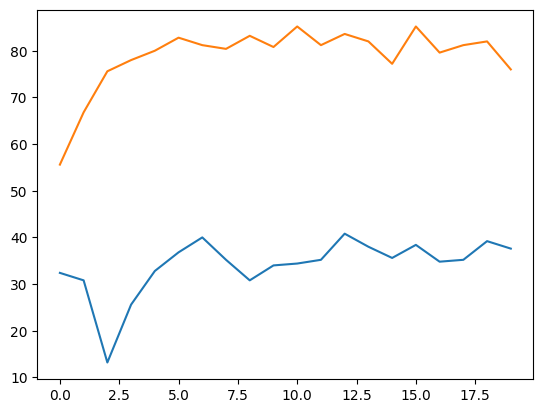

In [ ]:
plt.plot(val_acc, label='valid')
plt.plot(train_acc, label='train')
print(best)

In [ ]:
print(targets)
print(model.predict_on_batch(inputs))

[0. 0. 0. 0. 1. 1. 1. 1.]
[[5.1710978e-02]
 [2.5940402e-05]
 [6.7278033e-04]
 [5.4496431e-06]
 [9.7966045e-01]
 [9.6803778e-01]
 [9.9364412e-01]
 [9.9157059e-01]]


In [ ]:
(inputs, targets) = get_batch(batch_size, s='val')
print(targets)
print(model.predict_on_batch(inputs))

[0. 0. 0. 0. 1. 1. 1. 1.]
[[7.3025690e-04]
 [5.0504331e-04]
 [7.3448173e-05]
 [1.2726802e-05]
 [4.7660446e-01]
 [9.1450870e-01]
 [5.1634431e-01]
 [5.1634431e-01]]


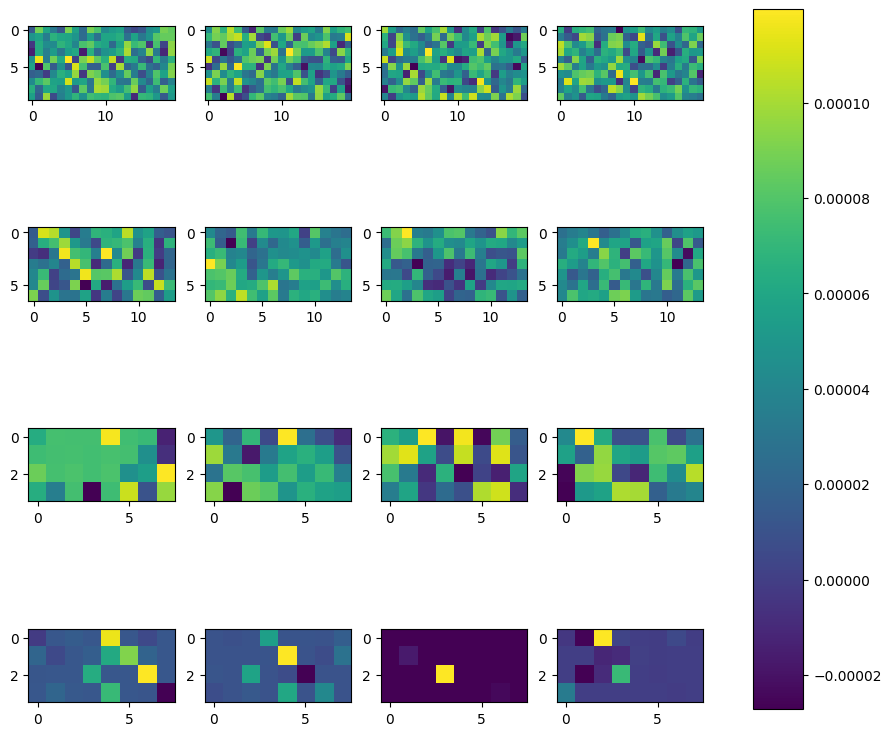

In [ ]:
fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(10, 10))
for i in range(4):
  for j in range(4):
    im=axs[i, j].imshow(model.layers[2].get_weights()[2 * i][:, :, 0, j])

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
fig.colorbar(im, cax=cbar_ax)
plt.show()

<BarContainer object of 2048 artists>

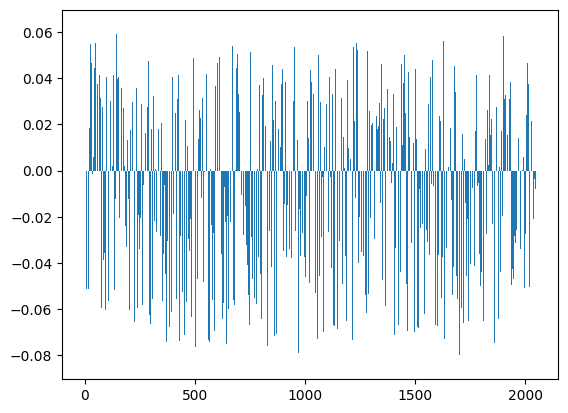

In [ ]:
plt.bar(np.arange(model.layers[4].get_weights()[0].shape[0]), model.layers[4].get_weights()[0][:,0])

## Compare with nearest neighbur, intensity and K distance methods

In [ ]:
def nearest_neighbour_correct(pairs, targets):
    """returns 1 if nearest neighbour gets the correct answer for a one-shot task
        given by (pairs, targets)"""
    L2_distances = np.zeros_like(targets)
    for i in range(len(targets)):
        L2_distances[i] = np.sum(np.sqrt((pairs[0][i] - pairs[1][i])**2))
    if np.argmin(L2_distances) == np.argmax(targets):
        return 1
    return 0

def test_nn_accuracy(N_ways, n_trials):
    """Returns accuracy of NN approach """
    print("Evaluating nearest neighbour on {} unique {} way one-shot learning tasks ...".format(n_trials,N_ways))

    n_right = 0
    for i in range(n_trials):
        pairs, targets, __, __ = make_oneshot_task(N_ways,"val")
        correct = nearest_neighbour_correct(pairs,targets)
        n_right += correct
    return 100.0 * n_right / n_trials

In [ ]:
def intensity_distance_correct(targets, cats, inds):
    """returns 1 if intensity distance gets the correct answer for a one-shot task
        given by (pairs, targets)"""
    rho_distances = np.zeros(len(cats))
    for i in range(len(cats)):
        rho_distances[i] = np.sum((bci_rhos[cats[0]][inds[0]] - bci_rhos[cats[i]][inds[1][i]])**2)
    if np.argmin(rho_distances) == np.argmax(targets):
        return 1
    return 0

def test_id_accuracy(N_ways, n_trials):
    """Returns accuracy of NN approach """
    print("Evaluating intensity distance on {} unique {} way one-shot learning tasks ...".format(n_trials, N_ways))

    n_right = 0

    for i in range(n_trials):
        __, targets, cat, ind = make_oneshot_task(N_ways,"val")
        correct = intensity_distance_correct(targets, cat, ind)
        n_right += correct
    return 100.0 * n_right / n_trials

In [ ]:
def Kfun_distance_correct(targets, cats, inds):
    """returns 1 if intensity distance gets the correct answer for a one-shot task
        given by (pairs, targets)"""
    K_dists = np.zeros(len(cats))
    for i in range(len(cats)):
        K_dists[i] = np.sum((bci_Ks[cats[0], inds[0], :] - bci_Ks[cats[i], inds[1][i], :])**2)
    if np.argmin(K_dists) == np.argmax(targets):
        return 1
    return 0

def test_Kf_accuracy(N_ways, n_trials):
    """Returns accuracy of NN approach """
    print("Evaluating K function distance on {} unique {} way one-shot learning tasks ...".format(n_trials, N_ways))

    n_right = 0

    for i in range(n_trials):
        __, targets, cat, ind = make_oneshot_task(N_ways,"val")
        correct = Kfun_distance_correct(targets, cat, ind)
        n_right += correct
    return 100.0 * n_right / n_trials

In [ ]:
ways = np.arange(2, 31, 2)
resume =  False
trials = 500

val_accs, train_accs, nn_accs, id_accs, kf_accs = [], [], [], [], []
for N in ways:
    val_accs.append(test_oneshot(model, N, trials, "val", verbose=True))
    train_accs.append(test_oneshot(model, N, trials, "train", verbose=True))
    nn_acc = test_nn_accuracy(N, trials)
    nn_accs.append(nn_acc)
    id_acc = test_id_accuracy(N, trials)
    id_accs.append(id_acc)
    kf_acc = test_Kf_accuracy(N, trials)
    kf_accs.append(kf_acc)
    print ("NN Accuracy = ", nn_acc)
    print ("ID Accuracy = ", id_acc)
    print ("KF Accuracy = ", kf_acc)
    print("---------------------------------------------------------------------------------------------------------------")


Evaluating model on 500 random 2 way one-shot learning tasks ... 

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 990ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━

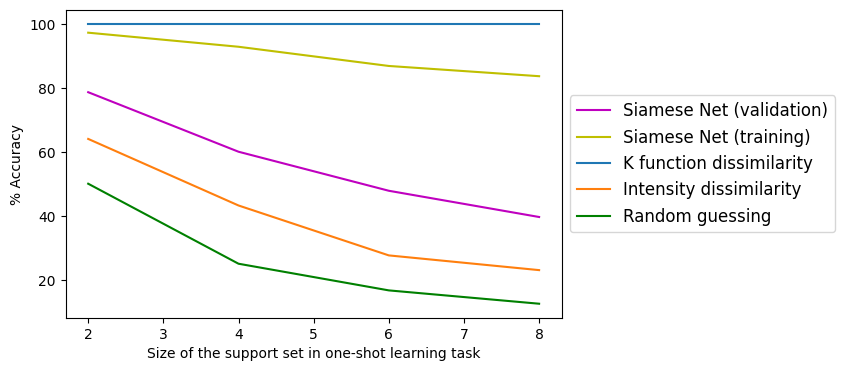

In [ ]:
fig, ax = plt.subplots(1, figsize=(8, 4))
ax.plot(ways, val_accs, "m", label="Siamese Net (validation)")
ax.plot(ways, train_accs, "y", label="Siamese Net (training)")
#plt.plot(ways, nn_accs, label="Nearest neighbour")
plt.plot(ways, kf_accs, label="K function dissimilarity")
plt.plot(ways, id_accs, label="Intensity dissimilarity")

ax.plot(ways, 100.0/ways, "g", label="Random guessing")
plt.xlabel("Size of the support set in one-shot learning task")
plt.ylabel("% Accuracy")
#plt.title("One-Shot Learning Performance for\nSimulated Point Patterns from 10 Processes",
#          fontsize=15)
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)
plt.show()

fig.savefig('bciaccuracy.pdf', bbox_inches='tight')

##Confusion matrix

In [ ]:
import seaborn as sn
from scipy.cluster.hierarchy import dendrogram, linkage

In [ ]:
pairs = [None] * 2
res1 = np.zeros((n_classes, n_classes))
for i in range(n_classes):
  for j in range(i, n_classes):
    tmp = []
    for k in range(n_examples):
      for l in range(n_examples):
        if ((i != j) or (k != l)):
          pairs[0] =  X[i, k, :, :].reshape(1, grid_ny, grid_nx, 1)
          pairs[1] =  X[j, l, :, :].reshape(1, grid_ny, grid_nx, 1)
          tmp.append(model.predict(pairs))
    tmp = np.asarray(tmp)
    res1[i, j] = res1[j, i] = tmp.mean()

#print(res1)
res1 = pd.DataFrame(res1, index = species, columns = species)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━

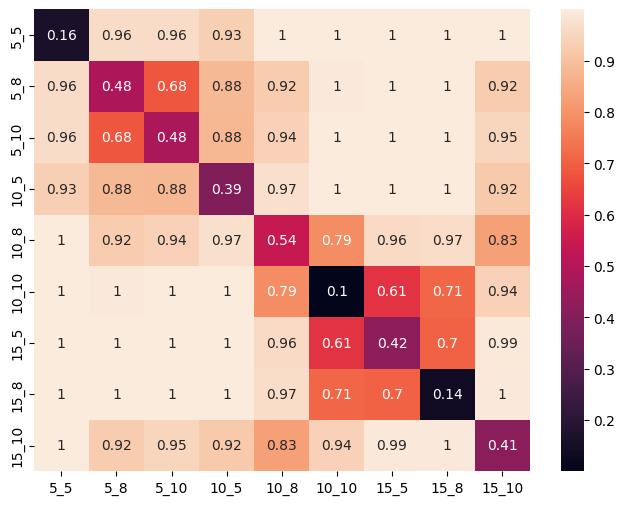

In [ ]:
plt.figure(figsize = (8, 6))
svm = sn.heatmap(1 - res1, annot=True)
fig = svm.get_figure()
#fig.savefig('bcicnnconfusion.pdf', bbox_inches='tight')

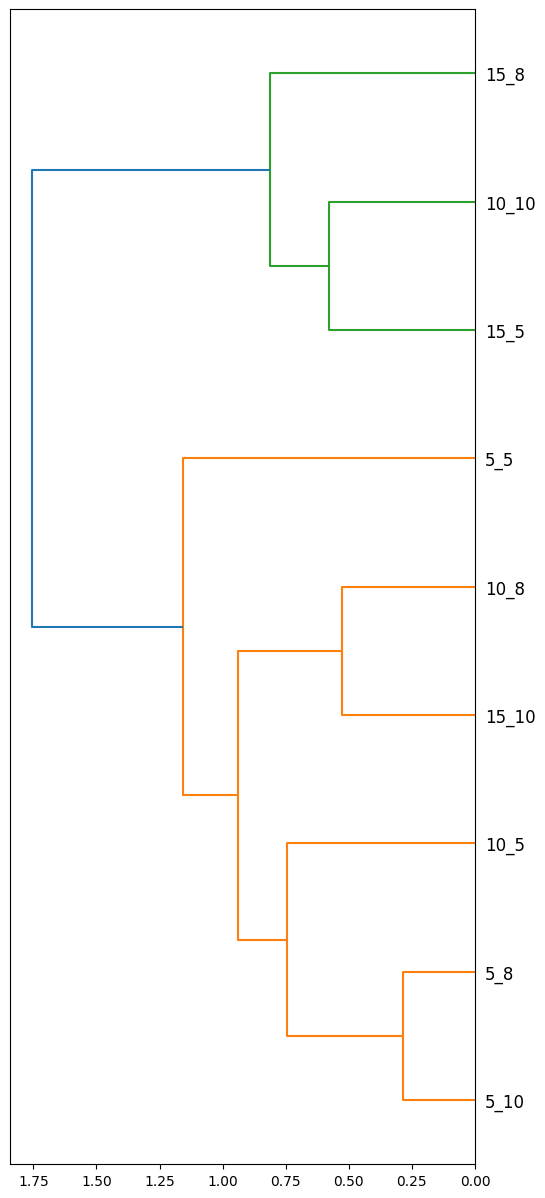

In [ ]:
linked = linkage(1 - res1, method='ward')
fig = plt.figure(figsize=(6, 15))
dendrogram(linked, orientation='left', labels=species,
            distance_sort='descending', show_leaf_counts=True)
plt.show()
fig.savefig('bcihc1.pdf', bbox_inches='tight')
plt.close()

In [ ]:
res2 = np.zeros((n_classes, n_classes))
for i in range(n_classes):
  for j in range(i, n_classes):
    tmp = []
    for k in range(n_examples):
      for l in range(k, n_examples):
        if ((i != j) or (k != l)):
          tmp.append(np.mean((bci_rhos[i, k, :] - bci_rhos[j, l, :])**2))
    tmp = np.asarray(tmp)
    res2[i, j] = res2[j, i] =  tmp.mean()

#print(res2)
res2 = pd.DataFrame(res2, index = species, columns = species)

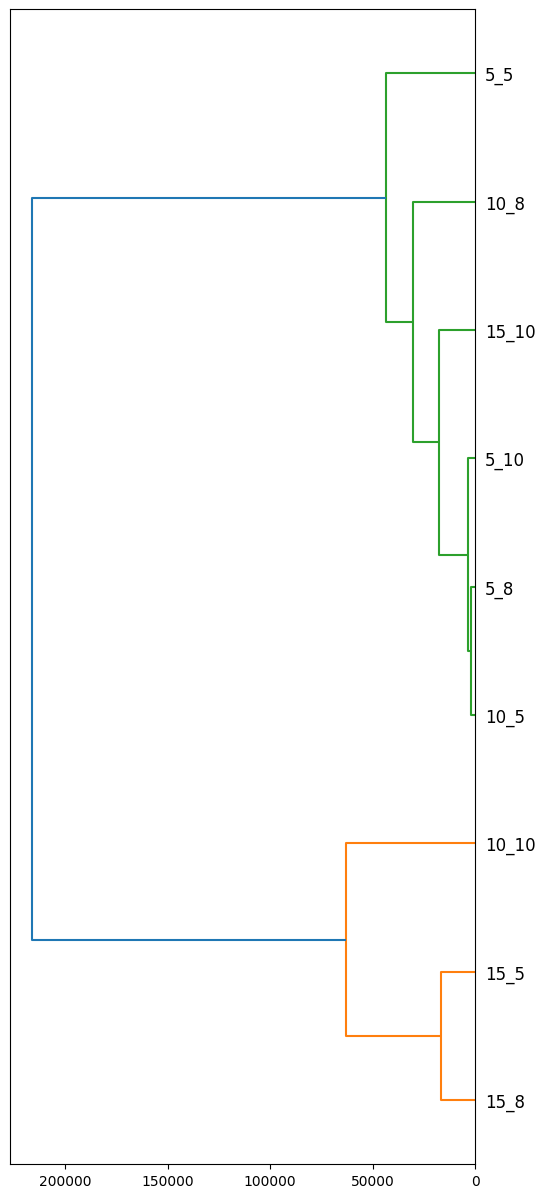

In [ ]:
linked = linkage(res2, 'ward')
fig = plt.figure(figsize=(6, 15))
dendrogram(linked, orientation='left', labels=species,
            distance_sort='descending', show_leaf_counts=True)
plt.show()
fig.savefig('bcihc2.pdf', bbox_inches='tight')
plt.close()

In [ ]:
np.sort(bci_imgs.sum(axis=(1, 2, 3)))

array([ 115.,  397.,  430.,  453.,  498.,  764., 1204., 1360., 1430.])

##References

https://sorenbouma.github.io/blog/oneshot/

https://towardsdatascience.com/one-shot-learning-with-siamese-networks-using-keras-17f34e75bb3d

https://medium.com/@crimy/one-shot-learning-siamese-networks-and-triplet-loss-with-keras-2885ed022352
